# 08 · importance는 무엇을 보장하는가: 새 activation과 실제 projection 오차

## 입력과 관찰 범위

로컬 원본 SmolLM2 checkpoint를 읽고 고정된 두 텍스트 prompt를 **새로 forward**한다. 12번 MLP down projection의 입력 $X\in\mathbb R^{t\times n}$과 가중치 $W\in\mathbb R^{n\times d}$를 사용한다. 이전 activation·importance·error 결과는 읽지 않는다. model snapshot, weight SHA256, prompt, layer, dtype를 기록한다. `VLM_CHECKPOINT`로 호환되는 로컬 원본 checkpoint를 지정할 수 있다. 없으면 명확히 실패하며 synthetic 데이터로 대체하지 않는다.

이는 LLM projection 실험이다. VLM의 visual tokens나 downstream task accuracy를 측정했다는 뜻은 아니다. 모든 mask는 고정 dense forward에서 얻은 같은 $X,W$로 평가하므로 여러 층을 동시에 sparsify한 누적 오차도 아니다.

$$Y=XW,\qquad Y_M=X\operatorname{diag}(M)W,\qquad
E(M)=\frac{\|Y-Y_M\|_F}{\|Y\|_F}.$$

## 실행 준비

결과는 `runs/08_importance_error/`에 저장합니다. 이 셀을 다시 실행하면 해당 폴더의 이전 결과를 지우고 새로 만듭니다.

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if (ROOT / "conclusion/python").is_dir():
    ROOT = ROOT / "conclusion/python"
sys.path.insert(0, str(ROOT))
import core as C
from reporting import begin, figure, finish
SEED = 20260926
RUN = begin(ROOT, "08_importance_error", SEED)

**결과:** `runs/08_importance_error/` · seed `20260926`

## 두 importance

$$v_i^{abs}=\frac1t\sum_u|X_{ui}|,\qquad
v_i^{energy}=\|X_{:i}\|_2^2\|W_{i:}\|_2^2.$$

후자는 rank-one contribution $A_i=X_{:i}W_{i:}$의 Frobenius norm 제곱이다. $I_v(M)=\sum_iv_iM_i$를 사용한다. $v^{abs}$를 많이 보존하는 것과 projection error 최소화는 일반적으로 동치가 아니다.

In [2]:
from capture import fresh_activations
samples, model_meta = fresh_activations(layers=(12,), seed=SEED)
(RUN / "model.json").write_text(json.dumps(model_meta, indent=2))
X, W = samples[12]
n = X.shape[1]
Y = X @ W
denominator = np.linalg.norm(Y)
assert denominator > 0
energy = np.square(X).sum(0) * np.square(W).sum(1)
scores = {"abs": np.abs(X).mean(0), "energy": energy}
s = 32
cost = C.two_line(n, s)
display(dict(tokens=X.shape[0], channels=n, output_width=W.shape[1], **model_meta))

{'tokens': 43,
 'channels': 2560,
 'output_width': 960,
 'checkpoint': '/home/yabsed/.cache/huggingface/hub/models--HuggingFaceTB--SmolLM2-360M-Instruct/snapshots/a10cc1512eabd3dde888204e902eca88bddb4951',
 'weights_sha256': 'e6bffe7435d7ddc10fd3b9a9efd429dafbacb1cb17015fb5562664e7532bf86e',
 'layers': [12],
 'prompts': ['Explain why a solid state drive can read one large contiguous block faster than many small scattered blocks.',
  'A scientist compares retained activation importance with projection error. Explain why these two quantities need not rank masks in the same order.'],
 'dtype': 'float32',
 'device': 'cpu',
 'threads': 4,
 'source': 'new local LLM forward passes; text inputs; no VLM task-accuracy claim'}

## 정리 6 · energy importance로 얻는 deterministic bound

누락 집합 $U=\{i:M_i=0\}$에 대해

$$Y-Y_M=\sum_{i\in U}A_i,\qquad
\|Y-Y_M\|_F\le\sum_{i\in U}\|A_i\|_F
\le\sqrt{|U|\sum_{i\in U}\|A_i\|_F^2}.$$

따라서 $D=\|Y\|_F^2>0$일 때

$$\boxed{E(M)^2\le\frac{(n-|M|)\,[I_{energy}(\mathbf1)-I_{energy}(M)]}{D}.}$$

$(n-|M|)$ 인자를 지운 식은 일반적으로 보장이 아니다. 서로 정렬된 contribution이 있으면 cross term이 누적된다. 두 contribution이 서로 상쇄하면 반대로 sum of energies가 실제 error를 크게 과대평가할 수도 있다.

$$\|\sum_{i\in U}A_i\|_F^2=\sum_{i\in U}\|A_i\|_F^2+2\sum_{i<j\in U}\langle A_i,A_j\rangle_F.$$

pairwise orthogonality가 성립하면 첫 항만 남지만 trained projection에서 이를 무검증으로 가정하지 않는다. bound가 실제 error보다 매우 큰 경우는 정리가 틀렸다는 뜻이 아니라 실용적 certificate가 약하다는 뜻이다.

## 비교 설계

같은 실제 $X,W$에서 abs/energy score 각각으로 Top-$R$, paper greedy, saturation tile mask를 새로 만든다. normalized importance, $E$, 위 bound, 선택 수를 모두 계산한다. 이 노트북의 $T$는 명시적인 **two-line 수학 모델**이며 SSD 실측값으로 표시하지 않는다. $s=32$도 가정한 행 길이다. 실제 I/O 연구와 error proxy 연구의 인과를 섞지 않기 위함이다.

모든 점에서 bound 위반 여부를 assert한다. $I$–$E$ scatter, error–model latency, score별 분포와 대표 mask를 그린다. synthetic 두-column 예제로 같은 importance에서도 상쇄 때문에 error가 달라지는 현상을 별도로 재현한다.

In [3]:
records, examples = [], {}
for score_name, score in scores.items():
    v = score / score.sum()
    for fraction in [.1, .25, .5, .75, .9, 1.]:
        r = int(round(n * fraction))
        methods = {"Top-R": C.topk(v, r), "Paper": C.paper(v, r, cost, s),
                   "Saturation": C.saturation(v, r, cost, s)}
        for method, mask in methods.items():
            error = np.linalg.norm(Y - X[:, mask] @ W[mask]) / denominator
            bound = np.sqrt((n-mask.sum()) * energy[~mask].sum()) / denominator
            assert error <= bound + 1e-9
            records.append(dict(score=score_name, method=method, fraction=fraction, selected=int(mask.sum()),
                                retained=v[mask].sum(), error=error, bound=bound,
                                model_latency=C.latency(mask, cost)))
            if fraction == .5:
                examples[f"{score_name}/{method}"] = mask
frame = pd.DataFrame(records)
frame.to_csv(RUN / "projection_errors.csv", index=False)
np.savez_compressed(RUN / "half_budget_masks.npz", **examples)
display(frame.groupby(["score", "method"])[["error", "bound"]].agg(["median", "max"]).round(4))


error            bound         
                   median     max   median      max
score  method                                      
abs    Paper       0.4395  0.8868  13.4236  39.6704
       Saturation  0.4685  0.9072  14.4701  40.1738
       Top-R       0.3071  0.7065   9.5520  31.8653
energy Paper       0.4253  0.8214  12.9823  36.5137
       Saturation  0.4578  0.8464  13.9925  37.3777
       Top-R       0.2974  0.6884   9.2618  30.9961

## 같은 energy라도 실제 오차는 달라질 수 있다

세 contribution 중 하나를 남기는 작은 예제로 상쇄 효과를 직접 확인합니다.

In [3]:
# Same retained energy, different error, with a nonzero full projection.
toy_x, toy_w = np.ones((1, 3)), np.array([[1.], [-1.], [1.]])
toy_y = toy_x @ toy_w
toy_errors = [float(np.linalg.norm(toy_y - toy_x[:, [i]] @ toy_w[[i]])) for i in range(3)]
assert toy_errors == [0., 2., 0.]
display(pd.DataFrame({"retained_energy": [1., 1., 1.], "absolute_error": toy_errors}))


,retained_energy,absolute_error
0,1.0,0.0
1,1.0,2.0
2,1.0,0.0


## 관측 · proxy와 실제 오차, bound의 느슨함

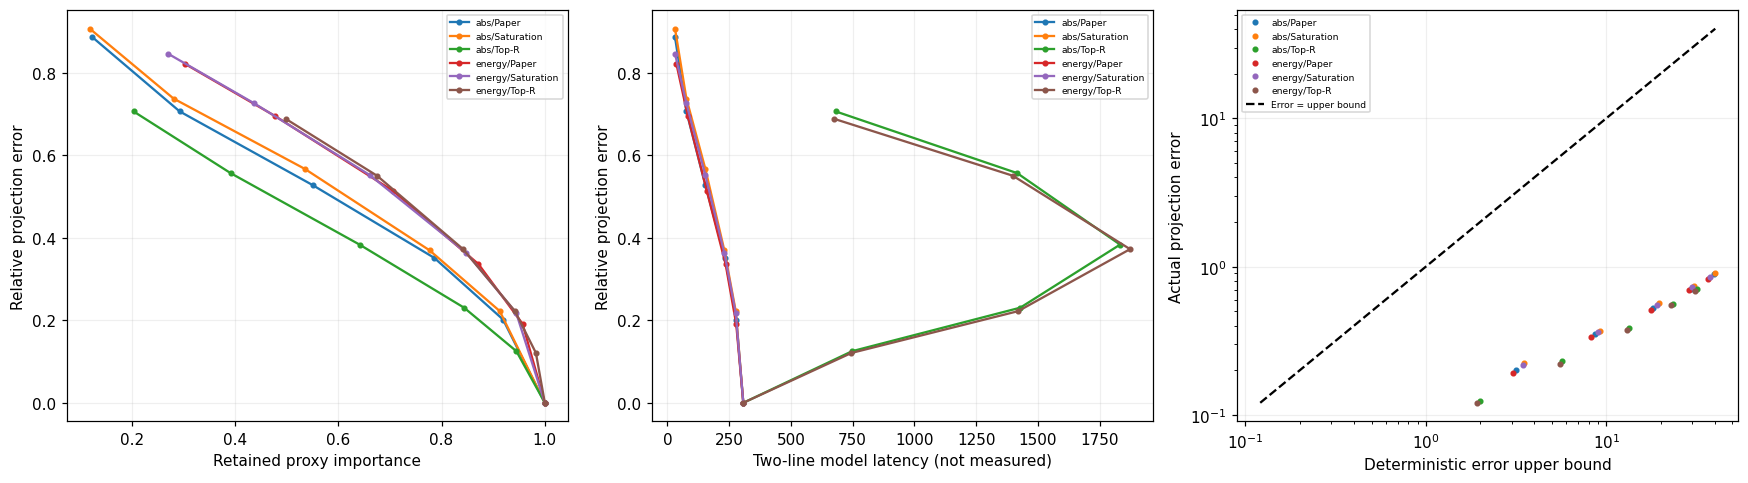

**실행에서 확인한 값**

- **fresh_forward_prompts**: 2

- **evaluated_masks**: 36

- **bound_violations**: 0

- **median_bound_to_error**: 34.5625887085293

- **equal_importance_counterexample_errors**: [0.0, 2.0, 0.0]

- **scope**: Fresh text LLM activations, one projection; neither VLM accuracy nor multi-layer propagated error

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for (score, method), group in frame.groupby(["score", "method"]):
    label = f"{score}/{method}"
    axes[0].plot(group.retained, group.error, ".-", label=label)
    axes[1].plot(group.model_latency, group.error, ".-", label=label)
    positive = group[(group.error > 1e-12) & (group.bound > 0)]
    axes[2].loglog(positive.bound, positive.error, ".", label=label)
axes[0].set(xlabel="Retained proxy importance", ylabel="Relative projection error")
axes[1].set(xlabel="Two-line model latency (not measured)", ylabel="Relative projection error")
positive = frame[(frame.error > 1e-12) & (frame.bound > 0)]
limits = [positive.error.min(), positive.bound.max()]
axes[2].loglog(limits, limits, "k--", label="Error = upper bound")
axes[2].set(xlabel="Deterministic error upper bound", ylabel="Actual projection error")
for ax in axes:
    ax.legend(fontsize=6)
figure(RUN, "importance_and_projection_error")
finish(RUN, fresh_forward_prompts=len(model_meta["prompts"]), evaluated_masks=len(frame),
       bound_violations=int((frame.error > frame.bound + 1e-9).sum()),
       median_bound_to_error=float((positive.bound/positive.error).median()),
       equal_importance_counterexample_errors=toy_errors,
       scope="Fresh text LLM activations, one projection; neither VLM accuracy nor multi-layer propagated error")

## 해석 기준

importance가 같으면 품질이 같다는 주장을 입증하려는 실험이 아니다. 대리 목적의 유효 범위와 실패 양상을 문서화한다. downstream 품질 결론에는 별도의 task 데이터와 전체 모델 forward가 필요하며, 이 노트북은 그 결과를 대신하지 않는다.